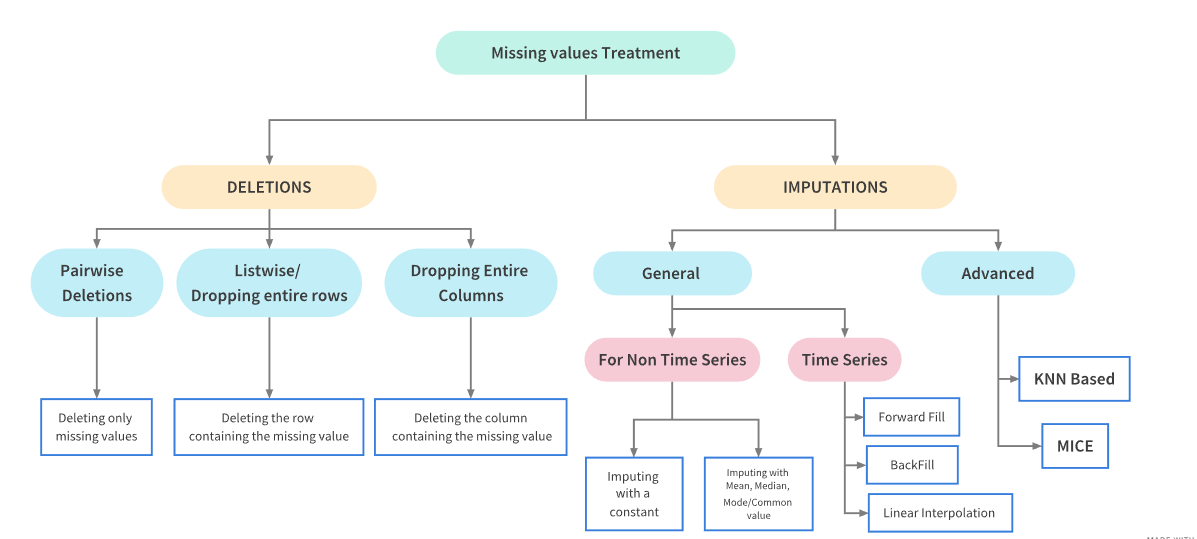

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [2]:
train=pd.read_csv('/kaggle/input/Tutorials/train.csv')
test=pd.read_csv('/kaggle/input/Tutorials/test.csv')

In [3]:
print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


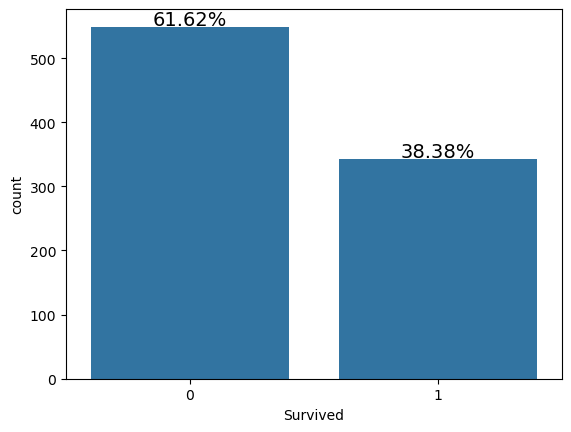

In [4]:
s = sns.countplot(x = 'Survived',data = train)
sizes=[]
for p in s.patches:
    height = p.get_height()
    sizes.append(height)
    s.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/len(train)*100),
            ha="center", fontsize=14) 

    


In [5]:
def missing_values_table(df):
    mis_val=df.isnull().sum()
    mis_val_percent=100 * df.isnull().sum()/len(df)
    mis_val_table=pd.concat([mis_val,mis_val_percent],axis=1)
    mis_val_rename_table_columns=mis_val_table.rename(columns={0:'Missing_values',1:'Total Missing Values Percentage'})
    mis_val_rename_table_columns=mis_val_rename_table_columns[mis_val_rename_table_columns.iloc[:,1]!=0].sort_values(by='Total Missing Values Percentage',ascending=False).round(1)
    return mis_val_rename_table_columns


In [6]:
train_missing=missing_values_table(train)
print(train_missing)

          Missing_values  Total Missing Values Percentage
Cabin                687                             77.1
Age                  177                             19.9
Embarked               2                              0.2


In [7]:
test_missing=missing_values_table(test)
print(test_missing)

       Missing_values  Total Missing Values Percentage
Cabin             327                             78.2
Age                86                             20.6
Fare                1                              0.2


# Analyising Missing Values using different techniques

<Axes: >

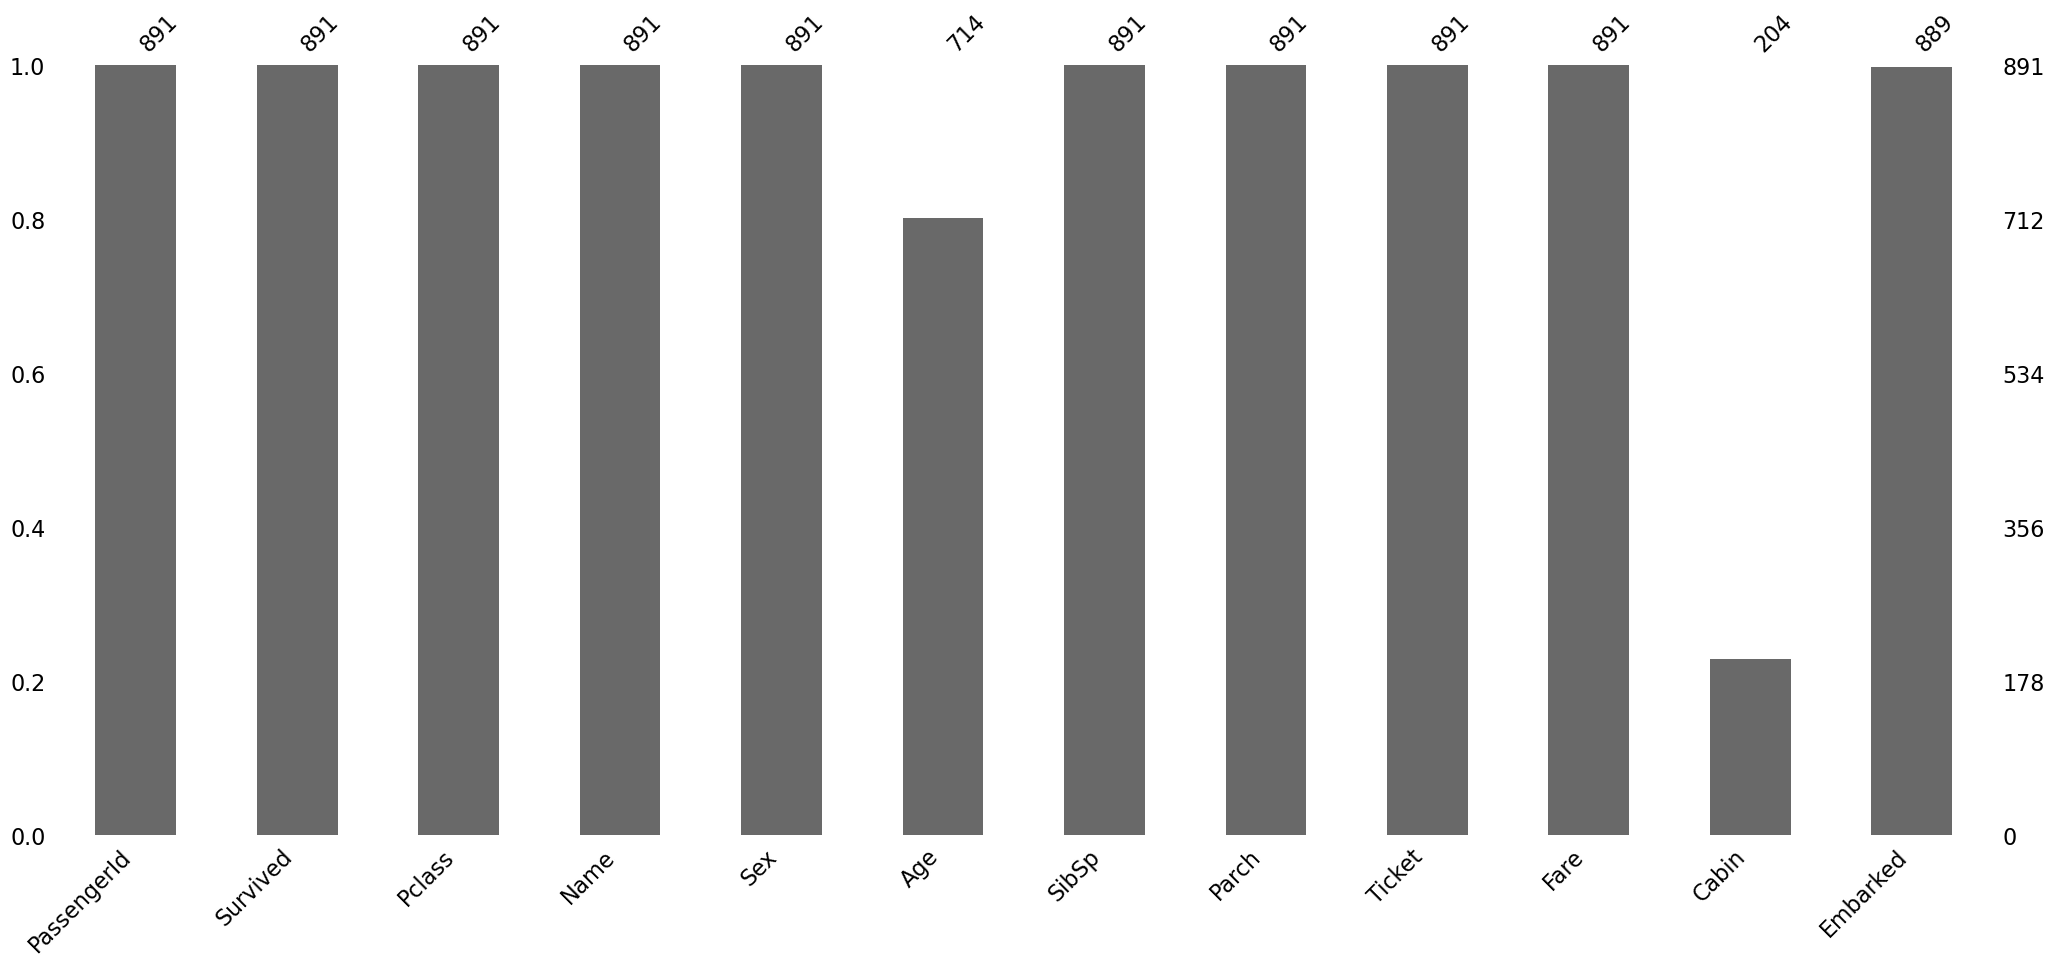

In [8]:
msno.bar(train)

<Axes: >

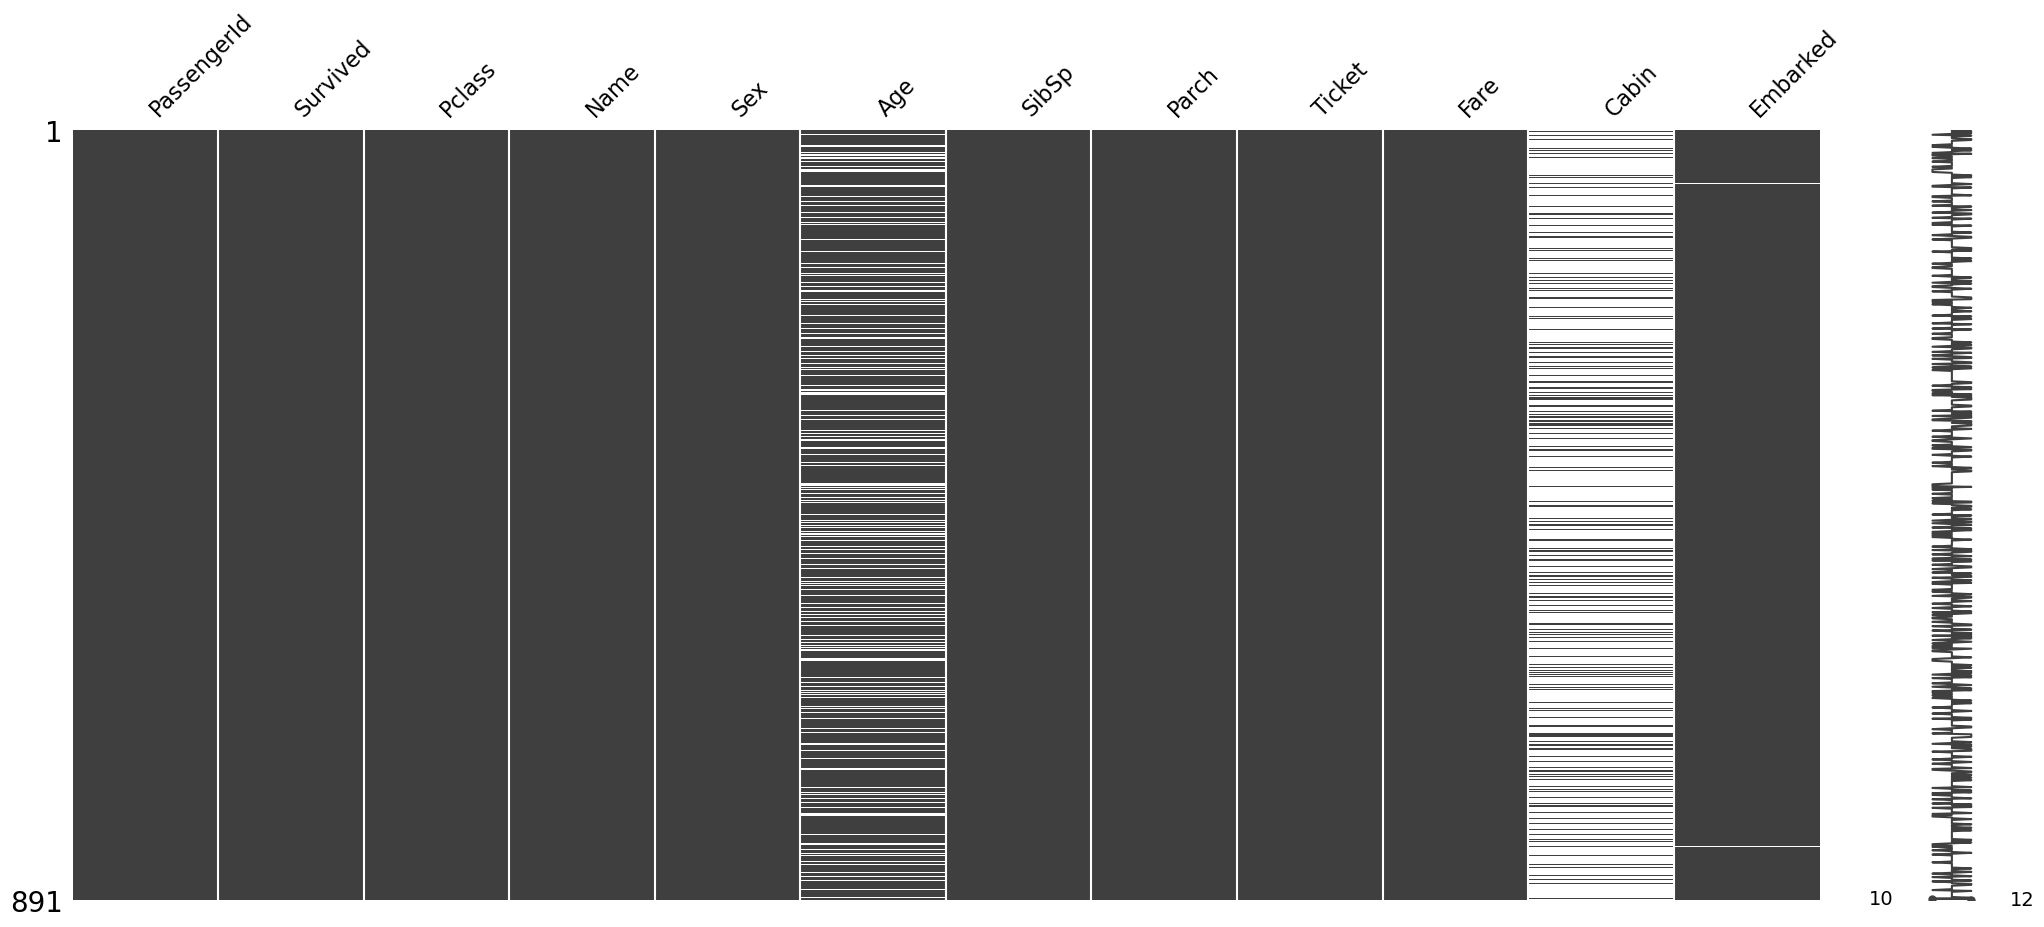

In [9]:
#The msno.matrix nullity matrix is a data-dense display which lets you quickly visually pick out patterns in data completion.
msno.matrix(train)

<Axes: >

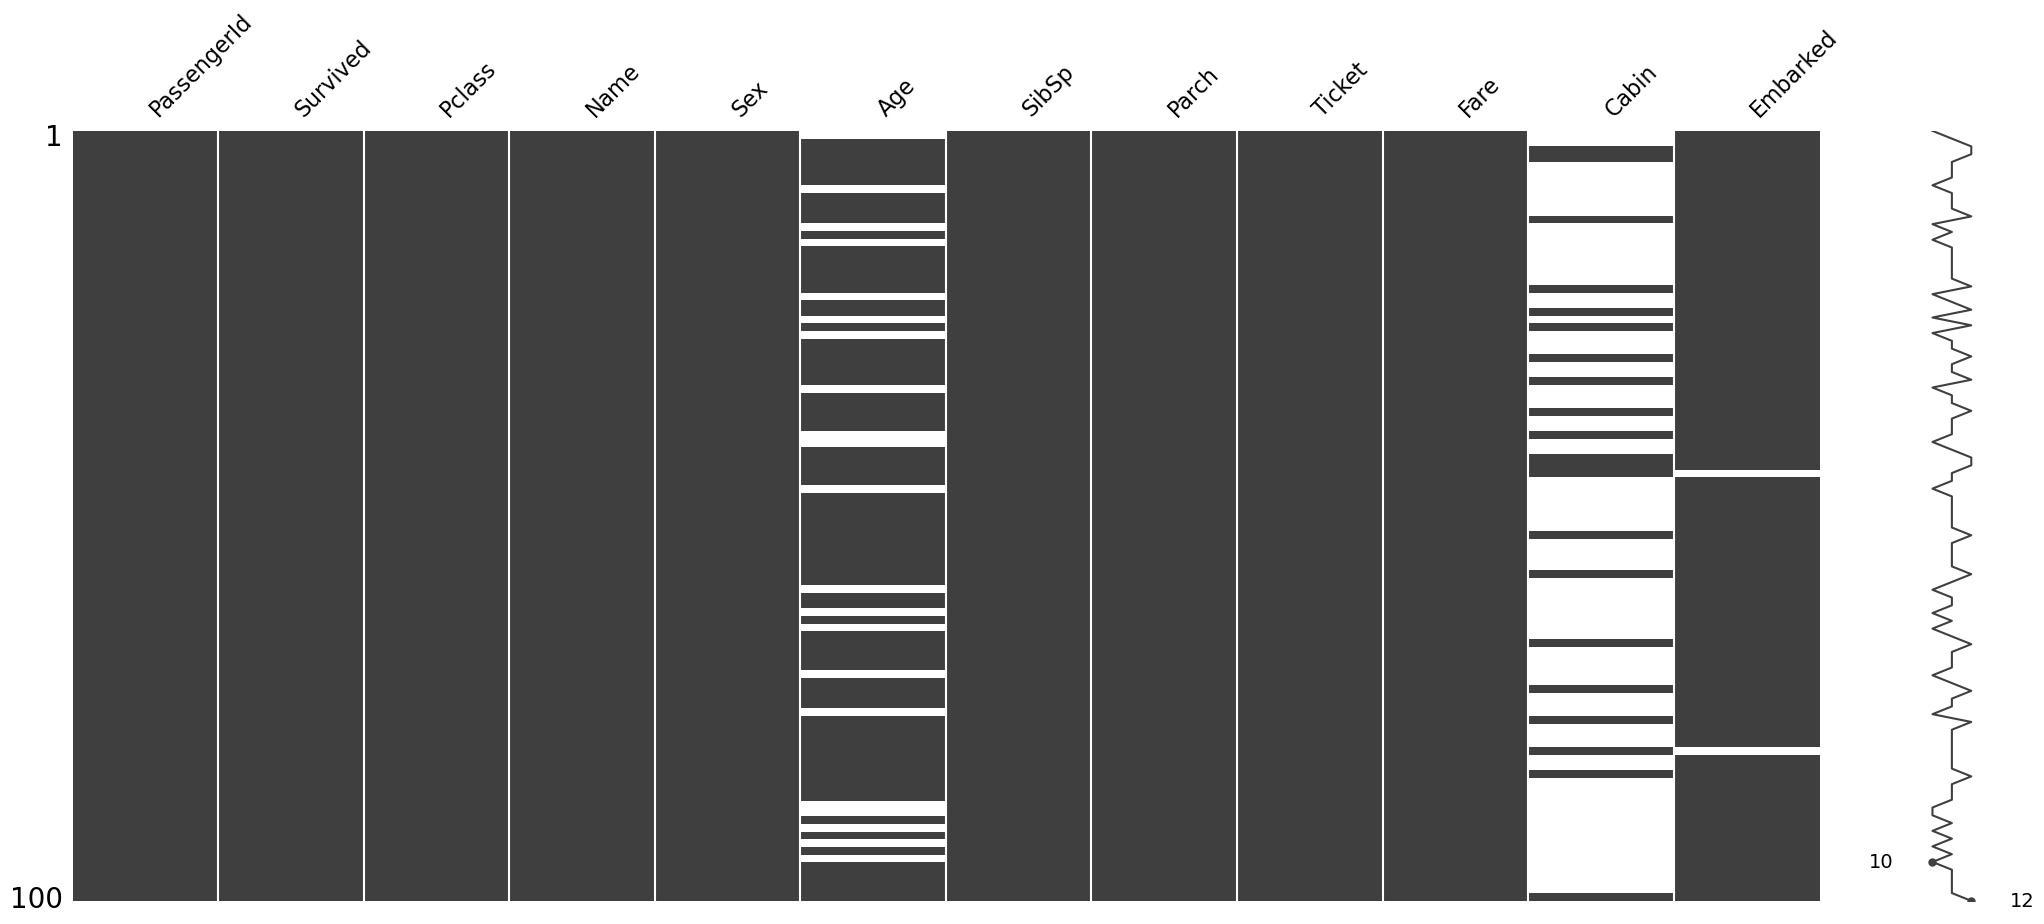

In [10]:
#It is also possible to sample the dataset to pinpoint the exact location of the missing values. For instance let's check the first 100 rows.
msno.matrix(train.sample(100))

<Axes: >

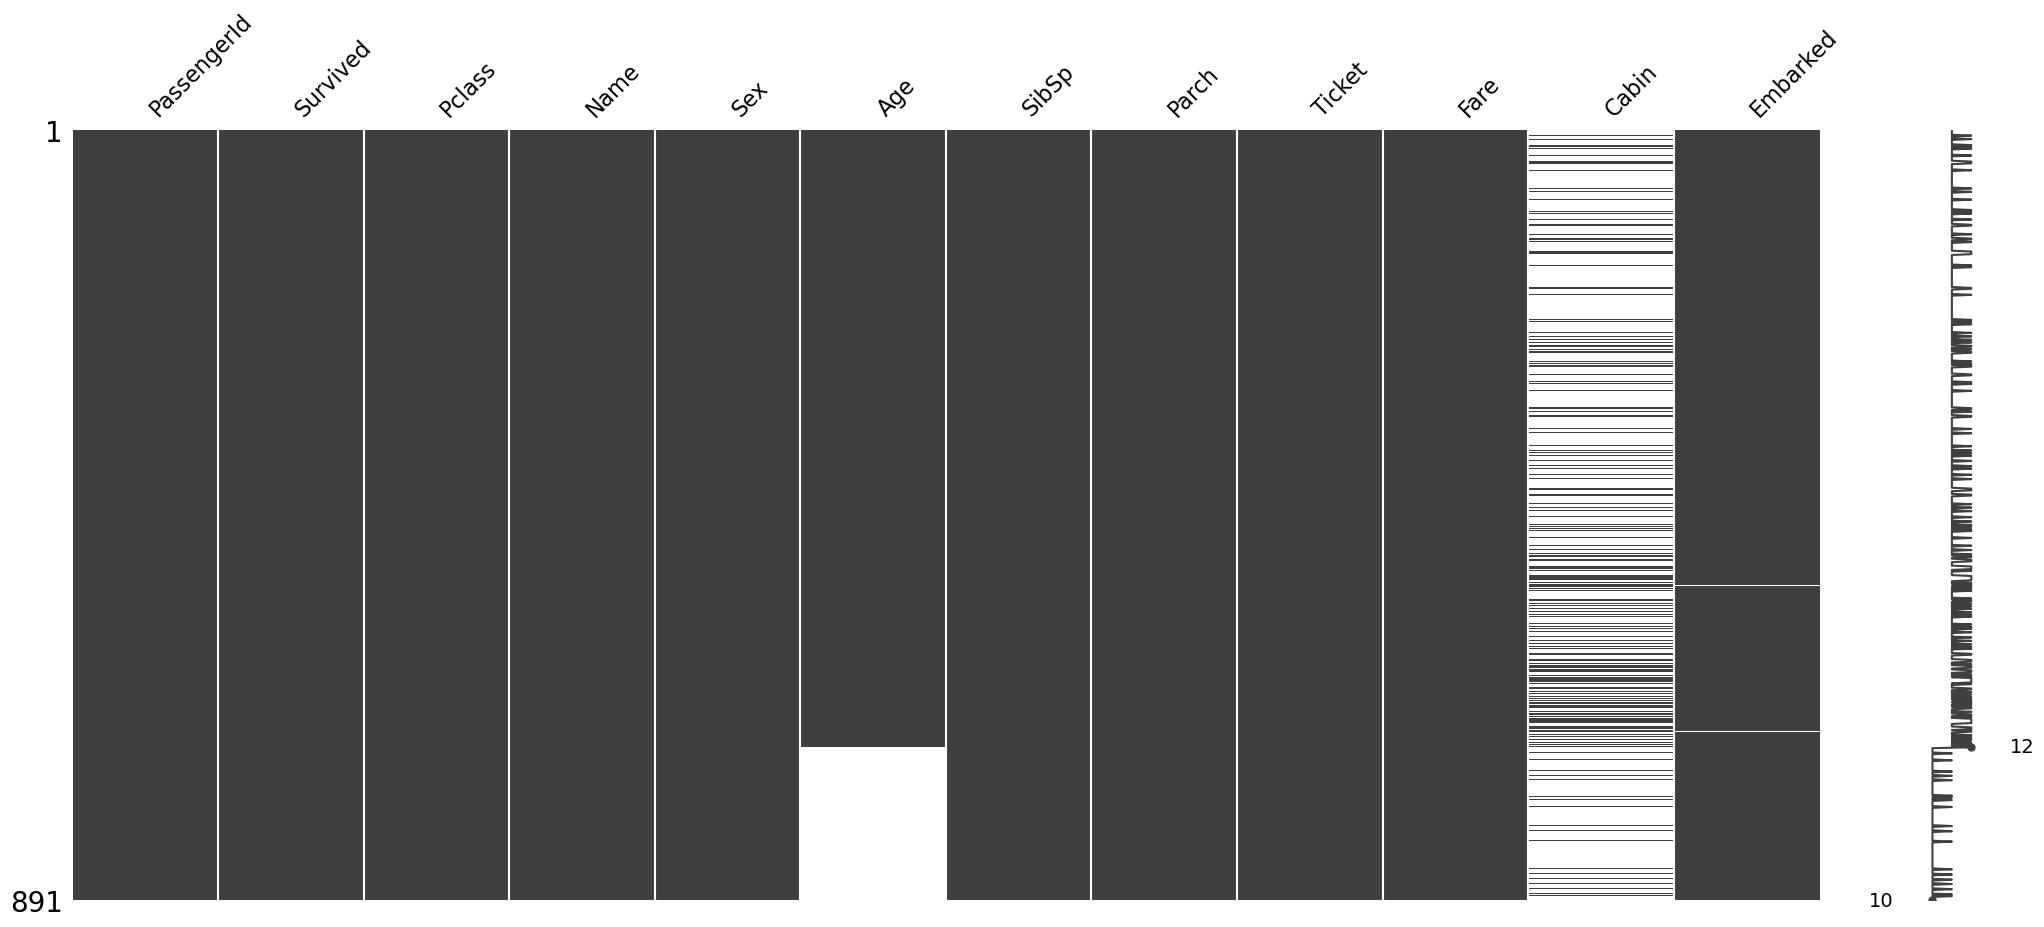

In [11]:
sorted=train.sort_values('Age')
msno.matrix(sorted)

<Axes: >

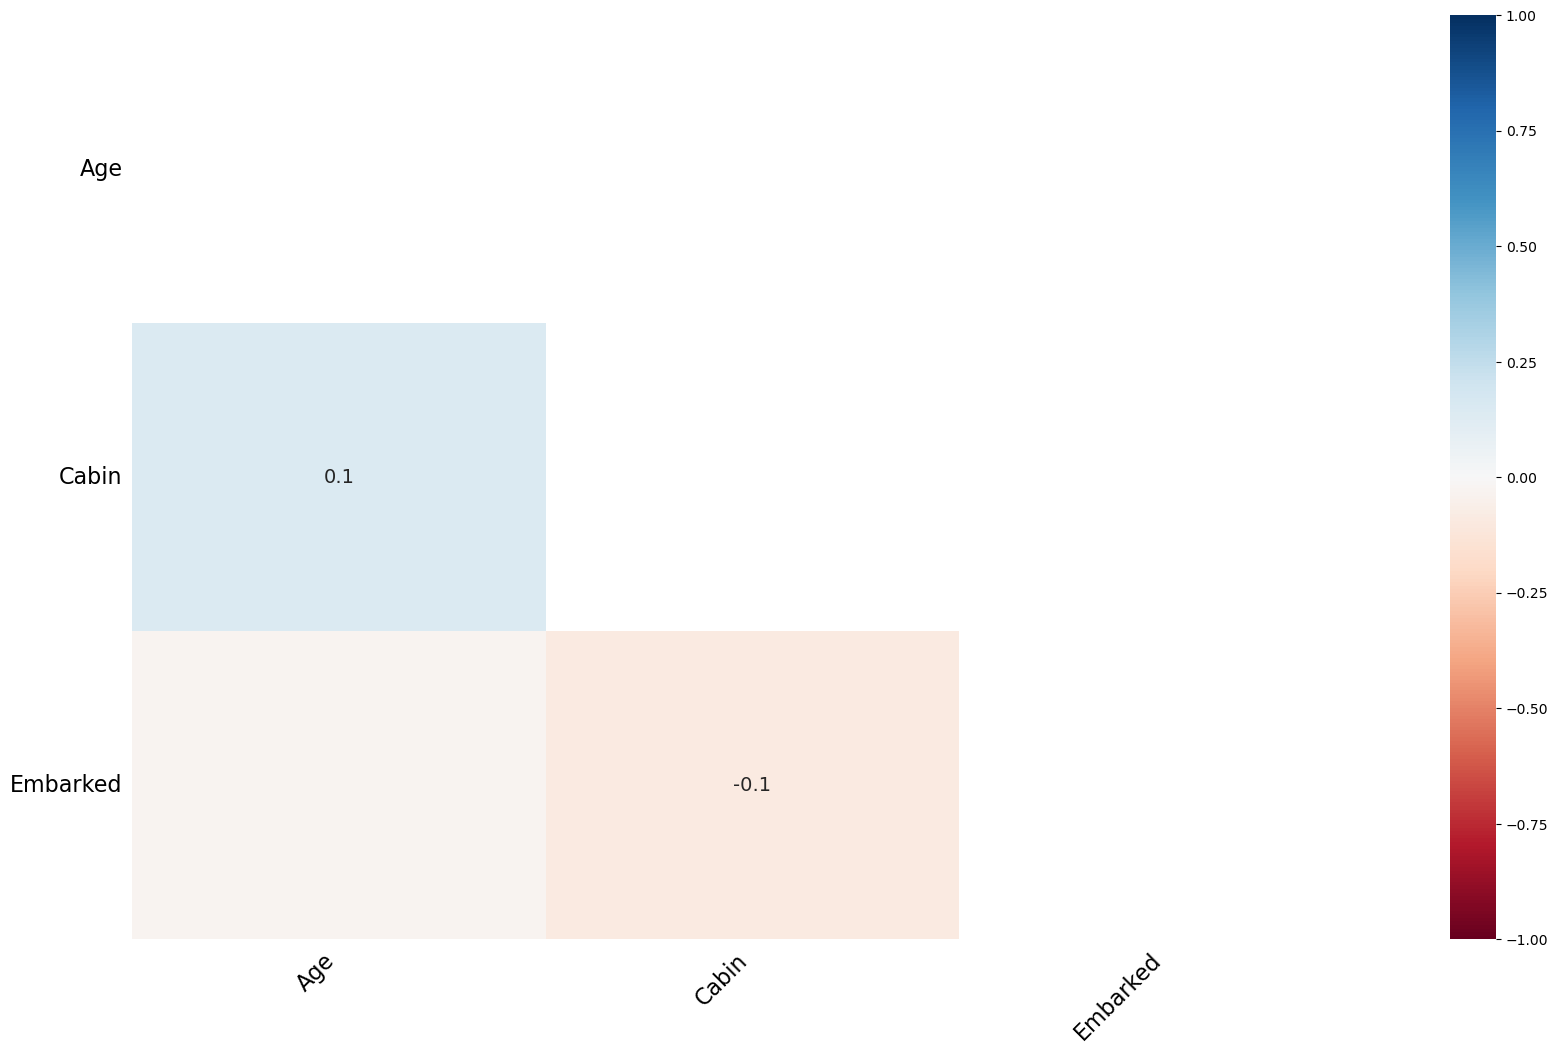

In [12]:
msno.heatmap(train)

<Axes: >

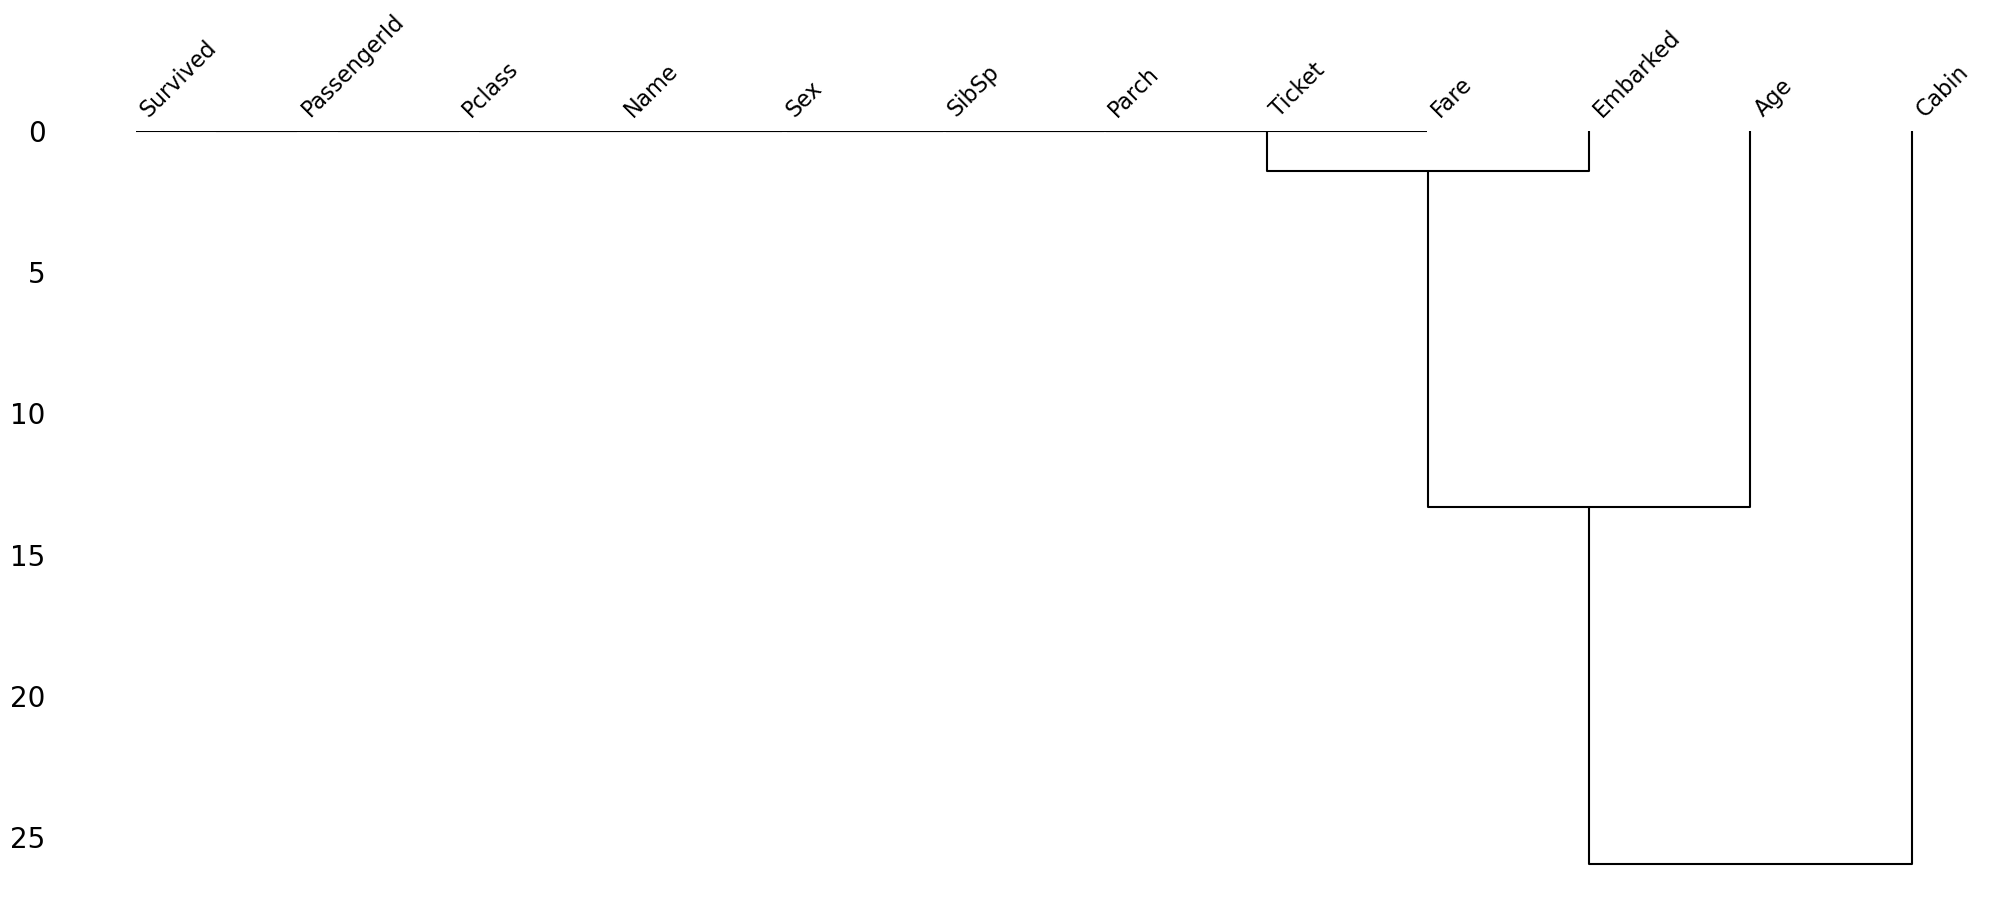

In [13]:
msno.dendrogram(train)

# Treating Missing Values

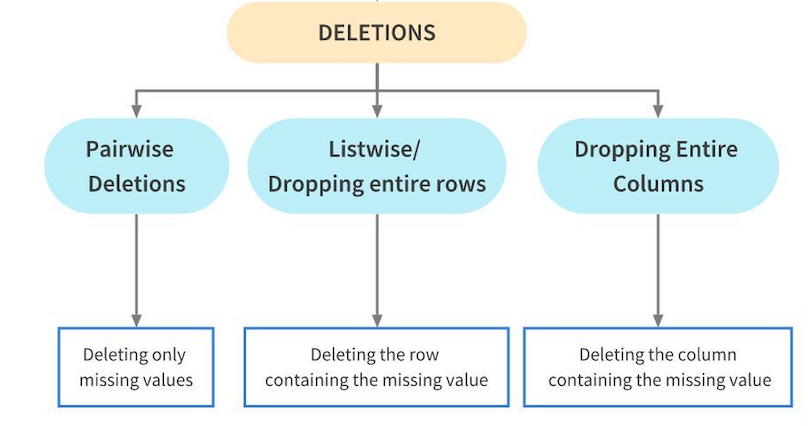

In [14]:
train_1=train.copy()
train_1['Age'].mean()

29.69911764705882

In [15]:
#ListWise Deletion/Dropping Rows
train_1.dropna(subset=['Age'],how='any',inplace=True)
train_1['Age'].isnull().sum()
#This should only be used when the no of missing values for that column are very small

0

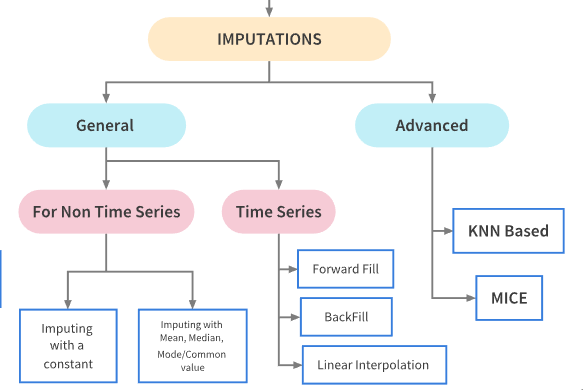

In [16]:
#Simple Imputation
from sklearn.impute import SimpleImputer
train_const=train.copy()
mean_imputer=SimpleImputer(strategy='constant')
train_const.iloc[:,:]=mean_imputer.fit_transform(train_const)
train_const.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Basic Imputation Techniques for Time Series Problems
* 'ffill' or 'pad' - Replace NaN s with last observed value
* 'bfill' or 'backfill' - Replace NaN s with next observed value
* Linear interpolation method

In [17]:
city_day=pd.read_csv('/kaggle/input/Tutorials/city_day.csv',parse_dates=True,index_col='Date')
city_day1=city_day.copy(deep=True)


In [18]:
city_day1.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
2015-01-02,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2015-01-03,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
2015-01-04,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
2015-01-05,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [21]:
city_missing_values=missing_values_table(city_day1)
city_missing_values

,Missing_values,Total Missing Values Percentage
Xylene,18109,61.3
PM10,11140,37.7
NH3,10328,35.0
Toluene,8041,27.2
Benzene,5623,19.0
AQI,4681,15.9
AQI_Bucket,4681,15.9
PM2.5,4598,15.6
NOx,4185,14.2
O3,4022,13.6
